# 提示词模板之ChatPromptTemplate的使用

1、实例化的方式（两种方式：使用构造方法、from_messages()）

2、调用提示词模板的几种方法：invoke() \ format() \ format_messages() \ format_prompt()

3、更丰富的实例化参数类型

4、结合LLM

5、插入消息列表：MessagePlaceholder

## 1、实例化的方式

方式1：使用构造方法

In [4]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate(
    messages=[
        ("system", "你是一个AI助手，你的名字叫{name}"),
        ("human", "我的问题是{question}")
    ],
    input_variables=["name", "question"],
)

response = chat_prompt_template.invoke({
    "name": "小智",
    "question": "1 + 2 * 3 - 2 = ?"
})

print("===== ChatPromptValue =====")
print(response)

print("\n===== 消息列表 =====")
print(response.messages)

print("\n===== 第一条消息 =====")
print(response.messages[0])

print("\n===== 第二条消息 =====")
print(response.messages[1])

print("\n===== 消息数量 =====")
print(len(response.messages))

===== ChatPromptValue =====

===== 消息列表 =====
[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1 + 2 * 3 - 2 = ?', additional_kwargs={})]

===== 第一条消息 =====
SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={})

===== 第二条消息 =====
HumanMessage(content='我的问题是1 + 2 * 3 - 2 = ?', additional_kwargs={})

===== 消息数量 =====
2


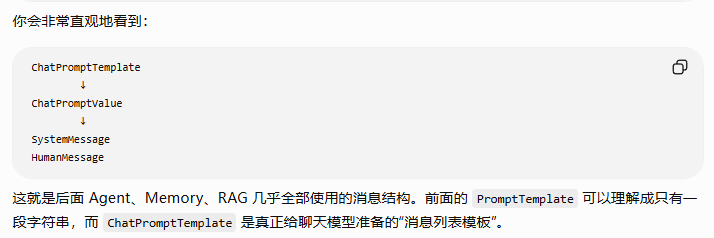

更简洁的方式：

In [6]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.invoke({
    "name": "小智",
    "question": "1 + 2 * 3 - 2 = ?"
})

print("===== ChatPromptValue =====")
print(response)

print("\n===== 类型 =====")
print(type(response))

print("\n===== 消息数量 =====")
print(len(response.messages))

print("\n===== 消息内容 =====")
for msg in response.messages:
    print(type(msg).__name__)
    print(msg.content)

===== ChatPromptValue =====

===== 类型 =====
<class 'langchain_core.ChatPromptValue'>

===== 消息数量 =====
2

===== 消息内容 =====
SystemMessage
你是一个AI助手，你的名字叫小智
HumanMessage
我的问题是1 + 2 * 3 - 2 = ?


方式2：调用from_message()  （官方推荐）


In [9]:
from langchain_core.prompts import ChatPromptTemplate

# 创建实例
# chat_prompt_template = ChatPromptTemplate([
#         ("system","你是一个AI助手，你的名字叫{name}"),
#         ("human","我的问题是{question}")
# ])

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.invoke({"name": "小智", "question": "1 + 2 * 3 = ？"})
print("===== 类型 =====")
print(type(response))

print("\n===== 消息数量 =====")
print(len(response.messages))

print("\n===== 消息列表 =====")
for msg in response.messages:
    print(type(msg).__name__)
    print(msg.content)
    print("-" * 30)

===== 类型 =====
<class 'langchain_core.ChatPromptValue'>

===== 消息数量 =====
2

===== 消息列表 =====
SystemMessage
你是一个AI助手，你的名字叫小智
------------------------------
HumanMessage
我的问题是1 + 2 * 3 = ？
------------------------------


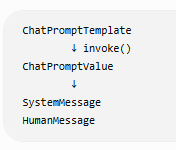

## 2、调用提示词模板的几种方法

invoke() \ format() \ format_messages() \ format_prompt()

invoke()：传入的是字典，返回ChatPromptValue

format():传入变量的值，返回str

format_messages(): 传入变量的值，返回消息构成的list

format_prompt(): 传入变量的值，返回ChatPromptValue

#举例1：invoke()

In [11]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.invoke({
    "name": "小智",
    "question": "1 + 2 * 3 = ?"
})

print("===== 类型 =====")
print(type(response))

print("\n===== 消息数量 =====")
print(len(response.messages))

print("\n===== 消息列表 =====")
for msg in response.messages:
    print(type(msg).__name__)
    print(msg.content)
    print("-" * 30)

===== 类型 =====
<class 'langchain_core.ChatPromptValue'>

===== 消息数量 =====
2

===== 消息列表 =====
SystemMessage
你是一个AI助手，你的名字叫小智
------------------------------
HumanMessage
我的问题是1 + 2 * 3 = ?
------------------------------


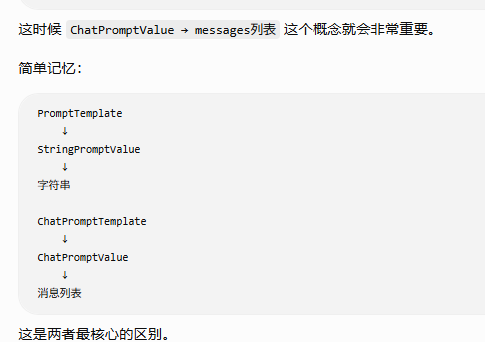

举例2：format()



In [12]:
from langchain_core.prompts import ChatPromptTemplate

# 创建实例

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.format(name="小智", question="1 + 2 * 3 = ？")
print(response)
print(type(response))

你是一个AI助手，你的名字叫小智
我的问题是1 + 2 * 3 = ？
<class 'str'>


举例3：format_messages()

In [13]:
from langchain_core.prompts import ChatPromptTemplate

# 创建实例

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.format_messages(name="小智", question="1 + 2 * 3 = ？")
print(response)
print(type(response))  #from langchain_core.prompts import ChatPromptTemplate

# 创建实例

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.format_messages(name="小智", question="1 + 2 * 3 = ？")
print(response)
print(type(response))  #<class 'list'>

[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1 + 2 * 3 = ？', additional_kwargs={})]
<class 'list'>
[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1 + 2 * 3 = ？', additional_kwargs={})]
<class 'list'>


举例4：format_prompt()



In [14]:
from langchain_core.prompts import ChatPromptTemplate

# 创建实例

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.format_prompt(name="小智", question="1 + 2 * 3 = ？")
print(response)
print(type(response))  #<class 'langchain_core.prompt_values.ChatPromptValue'>

<class 'langchain_core.ChatPromptValue'>


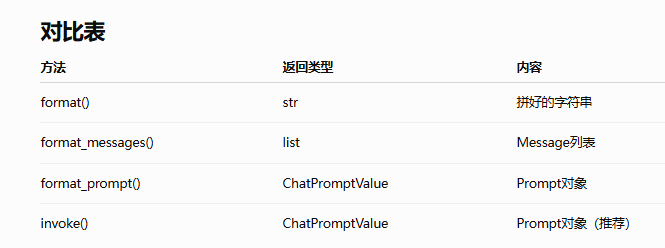

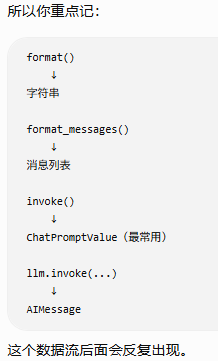

如何实现ChatPromptValue与list[messages]、字符串之间的转换

In [16]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

response = chat_prompt_template.invoke({
    "name":"小智",
    "question":"1 + 2 * 3 = ?"
})

print("===== ChatPromptValue =====")
print(type(response))

print("\n===== 转 list =====")
msgs = response.to_messages()
print(msgs)
print(type(msgs))

print("\n===== 转 string =====")
text = response.to_string()
print(text)
print(type(text))

===== ChatPromptValue =====
<class 'langchain_core.ChatPromptValue'>

===== 转 list =====
[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1 + 2 * 3 = ?', additional_kwargs={})]
<class 'list'>

===== 转 string =====
你是一个AI助手，你的名字叫小智
我的问题是1 + 2 * 3 = ?
<class 'str'>


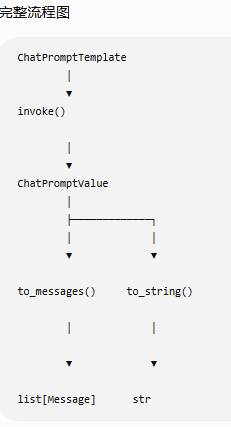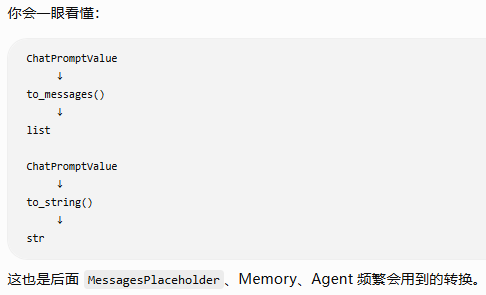

## 3、更丰富的实例化参数类型

本质：不管使用构造方法、还是使用from_message()来创建ChatPromptTemplate的实例，本质上来讲，传入的都是消息构成的列表。

从调用上来讲，我们看到，不管使用构造方法，还是使用from_message()，messages参数的类型都是列表，但是列表的元素的类型是多样的。元素可以是：

字符串类型、字典类型、消息类型、元组构成的列表（最常用、最基础、最简单）、Chat提示词模板类型、消息提示词模板类型

举例1：元组构成的列表（最常用、最基础、最简单）

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# 创建实例
#第1种方式
chat_prompt_template1 = ChatPromptTemplate(
    messages=[
        ("system", "你是一个AI助手，你的名字叫{name}"),
        ("human", "我的问题是{question}")
    ]
)
#第2种方式
chat_prompt_template2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

#
response = chat_prompt_template1.invoke({"name": "小智", "question": "1 + 2 * 3 = ？"})
for msg in response.messages:
    print(type(msg).__name__)
    print(msg.content)
    print("-" * 30)


SystemMessage
你是一个AI助手，你的名字叫小智
------------------------------
HumanMessage
我的问题是1 + 2 * 3 = ？
------------------------------


举例2：字符串



In [30]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate.from_messages([
    "我的问题是{question}"
])

response = chat_prompt_template.invoke({
    "question":"1 + 2 * 3 = ?"
})

print("===== 类型 =====")
print(type(response))

print("\n===== 消息列表 =====")
print(response.messages)

print("\n===== 第一条消息类型 =====")
print(type(response.messages[0]))

print("\n===== 内容 =====")
print(response.messages[0].content)

print("\n===== 字符串形式 =====")
print(response.to_string())

===== 类型 =====
<class 'langchain_core.ChatPromptValue'>

===== 消息列表 =====
[HumanMessage(content='我的问题是1 + 2 * 3 = ?', additional_kwargs={})]

===== 第一条消息类型 =====
<class 'langchain_core.HumanMessage'>

===== 内容 =====
我的问题是1 + 2 * 3 = ?

===== 字符串形式 =====
我的问题是1 + 2 * 3 = ?


举例3：字典类型


In [83]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    {
        "role":"system",
        "content":"我是{name}"
    },
    {
        "role":"human",
        "content":"问题:{question}"
    }
])

result = prompt.invoke({
    "name":"小智",
    "question":"1+2*3=?"
})

print(result.messages)

[HumanMessage(content='content', additional_kwargs={}), HumanMessage(content='content', additional_kwargs={})]


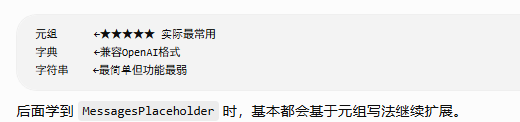

举例4：消息类型


In [82]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate

chat_prompt_template = ChatPromptTemplate.from_messages([
    SystemMessage(content="我是一个人工智能助手，我的名字叫{name}"),
    HumanMessage(content="我的问题是{question}")
])

response = chat_prompt_template.invoke({
    "name": "小智",
    "question": "1 + 2 * 3 = ?"
})

print(response)
print(response.messages)
print(response.to_string())

[SystemMessage(content='我是一个人工智能助手，我的名字叫{name}', additional_kwargs={}), HumanMessage(content='我的问题是{question}', additional_kwargs={})]
我是一个人工智能助手，我的名字叫{name}
我的问题是{question}


举例5：Chat提示词模板类型  ChatPromptTemplate 嵌套 ChatPromptTemplate


In [84]:
from langchain_core.prompts import ChatPromptTemplate

# 使用 BaseChatPromptTemplate（嵌套的 ChatPromptTemplate）
nested_prompt_template1 = ChatPromptTemplate.from_messages([
    ("system", "我是一个人工智能助手，我的名字叫{name}")
])
nested_prompt_template2 = ChatPromptTemplate.from_messages([
    ("human", "很高兴认识你,我的问题是{question}")
])

prompt_template = ChatPromptTemplate.from_messages([
    nested_prompt_template1,
    nested_prompt_template2
])

prompt_template.format_messages(name="小智", question="你为什么这么帅？")

[SystemMessage(content='我是一个人工智能助手，我的名字叫小智', additional_kwargs={}),
 HumanMessage(content='很高兴认识你,我的问题是你为什么这么帅？', additional_kwargs={})]

In [86]:
system_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是资深Python专家")
])

user_prompt = ChatPromptTemplate.from_messages([
    ("human", "{question}")
])

final_prompt = ChatPromptTemplate.from_messages([
    system_prompt,
    user_prompt
])

messages = final_prompt.format_messages(
    question="什么是装饰器？"
)

print(messages)

[SystemMessage(content='你是资深Python专家', additional_kwargs={}), HumanMessage(content='什么是装饰器？', additional_kwargs={})]


举例6：消息提示词模板类型

In [87]:
# 导入聊天消息类模板
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate

# 创建消息模板
system_template = "你是一个专家{role}"
system_message_prompt = SystemMessagePromptTemplate.from_template(system_template)

human_template = "给我解释{concept}，用浅显易懂的语言"
human_message_prompt = HumanMessagePromptTemplate.from_template(human_template)

# 组合成聊天提示模板
chat_prompt = ChatPromptTemplate.from_messages([
    system_message_prompt, human_message_prompt
])

# 格式化提示
formatted_messages = chat_prompt.format_messages(
    role="物理学家",
    concept="相对论"
)
print(formatted_messages)

[SystemMessage(content='你是一个专家物理学家', additional_kwargs={}), HumanMessage(content='给我解释相对论，用浅显易懂的语言', additional_kwargs={})]


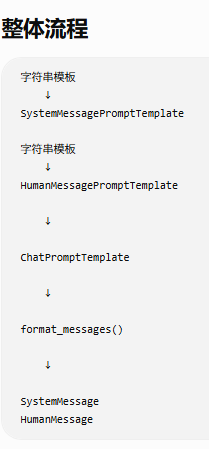

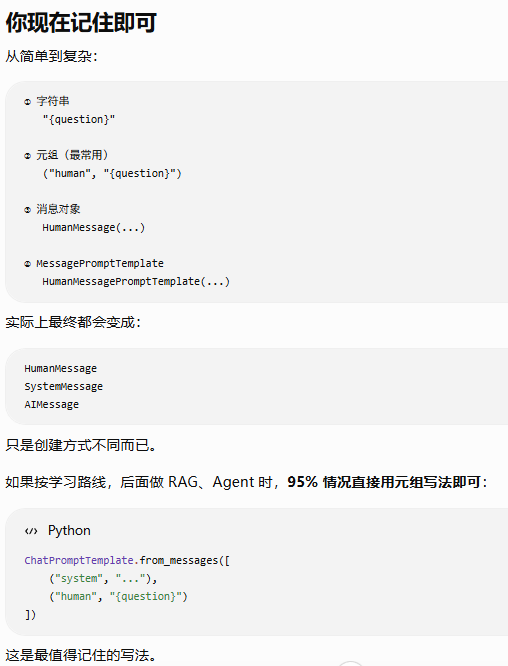

## 4、结合LLM

In [88]:
# 1、提供大模型
from langchain_openai import ChatOpenAI
import os
import dotenv

#加载配置文件
dotenv.load_dotenv()

os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY1")

# 获取对话模型：
chat_model = ChatOpenAI(
    model="qwen2.5-coder:1.5b"
)

# 2、通过Chat提示词模板，创建提示词
from langchain_core.prompts import ChatPromptTemplate

# 创建实例
chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    ("human", "我的问题是{question}")
])

prompt_response = chat_prompt_template.invoke({"name": "小智", "question": "1 + 2 * 3 = ？"})

# 3、通过大模型调用提示词，得到响应数据
response = chat_model.invoke(prompt_response)
print(response)

AIMessage(content='1 + 2 * 3 = 7', additional_kwargs={})


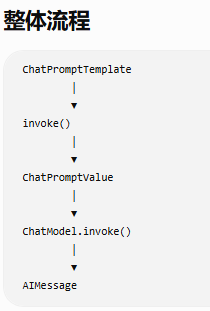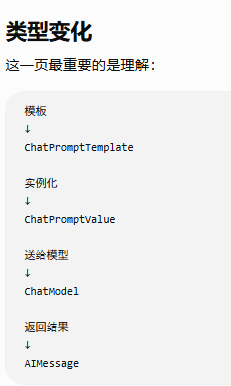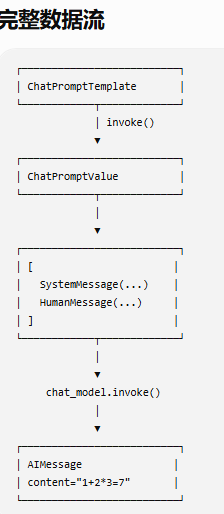

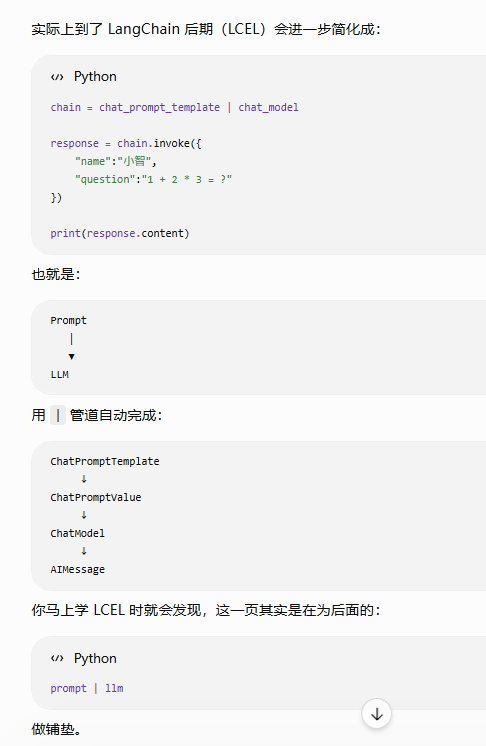

## 5、插入消息列表：MessagePlaceholder

使用场景：当ChatPromptTemplatem模板中的消息类型和个数不确定的时候，我们就可以使用MessagePlaceholder。

举例1：




In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts.chat import MessagesPlaceholder

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    MessagesPlaceholder(variable_name="msgs")
])

chat_prompt_template.invoke({
    "name": "小智",
    "msgs": [HumanMessage(content="我的问题是：1 + 2 * 3 = ?")]
})
response = chat_prompt_template.invoke({
    "name":"小智",
    "msgs":[
        HumanMessage(
            content="我的问题是1+2*3=?"
        )
    ]
})

print(response.messages)

[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1+2*3=?', additional_kwargs={})]


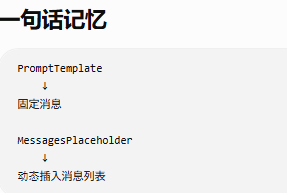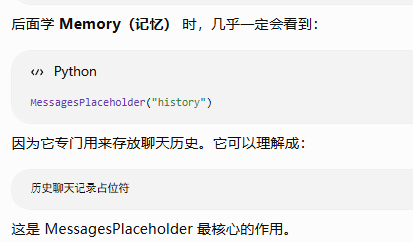

举例2：

In [93]:
from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts.chat import MessagesPlaceholder

chat_prompt_template = ChatPromptTemplate.from_messages([
    ("system", "你是一个AI助手，你的名字叫{name}"),
    MessagesPlaceholder(variable_name="msgs")
])

chat_prompt_template.invoke({
    "name": "小智",
    "msgs": [HumanMessage(content="我的问题是：1 + 2 * 3 = ?"),AIMessage(content="1 + 2 * 3 = 7")]
})
response = chat_prompt_template.invoke({
    "name":"小智",
    "msgs":[
        HumanMessage(
            content="我的问题是1 + 2 * 3 = ?"
        ),
        AIMessage(
            content="1 + 2 * 3 = 7"
        )
    ]
})

print(response.messages)

[SystemMessage(content='你是一个AI助手，你的名字叫小智', additional_kwargs={}), HumanMessage(content='我的问题是1 + 2 * 3 = ?', additional_kwargs={}), AIMessage(content='1 + 2 * 3 = 7', additional_kwargs={})]


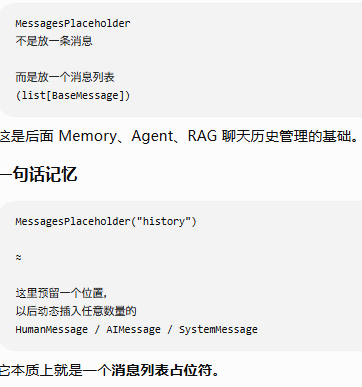

举例3：存储对话历史记录

In [94]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        MessagesPlaceholder("history"),
        ("human", "{question}")
    ]
)

prompt_value = prompt.format_messages(
    history=[HumanMessage(content="1+2*3 = ?"),AIMessage(content="1+2*3=7")],
    question="我刚才问题是什么？")

print(prompt_value)

# prompt.invoke(
#     {
#         "history": [("human", "what's 5 + 2"), ("ai", "5 + 2 is 7")],
#         "question": "now multiply that by 4"
#     }
# )

[SystemMessage(content='You are a helpful assistant.', additional_kwargs={}), HumanMessage(content='1+2*3 = ?', additional_kwargs={}), AIMessage(content='1+2*3=7', additional_kwargs={}), HumanMessage(content='我刚才问题是什么？', additional_kwargs={})]


In [ ]:

from langchain_openai import ChatOpenAI
import os
import dotenv

#加载配置文件
dotenv.load_dotenv()

os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY1")

# 获取对话模型：
chat_model = ChatOpenAI(
    model="qwen2.5-coder:1.5b"
)

chat_model.invoke(prompt_value)